**Re-define virality with new data as a threshold of reposts on the post x amount of hours after creation.**

In [3]:
import pandas as pd
import numpy as np
from kneed import KneeLocator
import duckdb
import json
import tarfile
import matplotlib.pyplot as plt
from pathlib import Path
import sys


In [8]:
BASE_PATH = Path.cwd().parent
sys.path.append(str(BASE_PATH))
reposts = pd.read_parquet(BASE_PATH/"datasets/bluesky_cascade/reposts.parquet")
#print(reposts)
print(reposts.columns)
print(reposts.repost_time_us)
print(reposts.created_at)

Index(['root_post_uri', 'reposter_did', 'repost_time_us', 'created_at',
       'reposter_followers', 'reposter_follows', 'time_delta_sec'],
      dtype='str')
0         1776000866789204
1         1776000878753759
2         1776000894108024
3         1776000900559799
4         1776000913108994
                ...       
169018    1776093327492433
169019    1776093732487701
169020    1776093852012286
169021    1776094000120936
169022    1776094086134309
Name: repost_time_us, Length: 169023, dtype: int64
0         2026-04-12T13:34:26.329Z
1         2026-04-12T13:34:38.405Z
2         2026-04-12T13:34:53.774Z
3         2026-04-12T13:34:59.484Z
4         2026-04-12T13:35:12.413Z
                    ...           
169018    2026-04-13T15:15:27.455Z
169019    2026-04-13T15:22:10.184Z
169020    2026-04-13T15:24:10.564Z
169021    2026-04-13T15:26:39.497Z
169022    2026-04-13T15:28:02.037Z
Name: created_at, Length: 169023, dtype: str


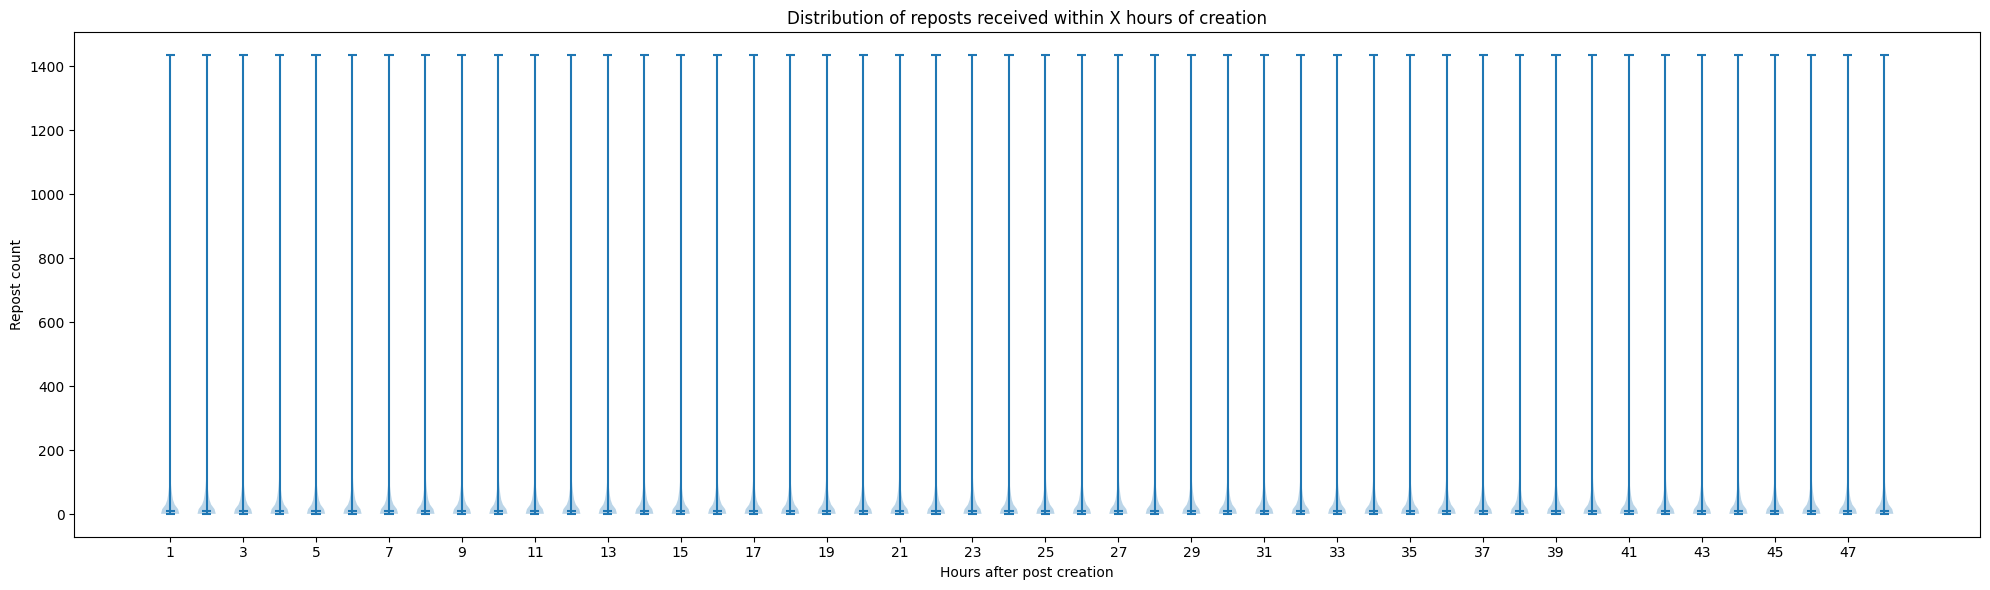

In [ ]:
# Get distribution of reposts after x hours, increments of 1 hour
repost_dist_after_each_num_hours = {}
MIN_HOURS = 1
MAX_HOURS = 72
INCREMENT_HOURS = 1

for hours in range(MIN_HOURS, MAX_HOURS+1):
    df = duckdb.query(f"""
        SELECT 
            root_post_uri,
            COUNT(*) as repost_count
        FROM reposts
        WHERE epoch_us(created_at::TIMESTAMPTZ) <= repost_time_us
        AND repost_time_us <= epoch_us(created_at::TIMESTAMPTZ) + ({hours} * 3600::BIGINT * 1000000)
        GROUP BY root_post_uri
    """).df()
    repost_dist_after_each_num_hours[hours] = df["repost_count"].values

# Plot
fig, ax = plt.subplots(figsize=(20, 6))

ax.violinplot(
    [repost_dist_after_each_num_hours[h] for h in range(MIN_HOURS, MAX_HOURS+1)],
    positions=range(MIN_HOURS, MAX_HOURS+1),
    showmedians=True
)

ax.set_xlabel("Hours after post creation")
ax.set_ylabel("Repost count")
ax.set_title("Distribution of reposts received within X hours of creation")
ax.set_xticks(range(MIN_HOURS, MAX_HOURS+1, 2))
plt.tight_layout()
plt.show()

This doesn't show much, since it's rouhgly power law distributed. Instead let's find the knee of the distribution over time.

Hour  1: knee at 7 reposts
Hour  2: knee at 7 reposts
Hour  3: knee at 7 reposts
Hour  4: knee at 7 reposts
Hour  5: knee at 7 reposts
Hour  6: knee at 7 reposts
Hour  7: knee at 7 reposts
Hour  8: knee at 7 reposts
Hour  9: knee at 7 reposts
Hour 10: knee at 7 reposts
Hour 11: knee at 7 reposts
Hour 12: knee at 7 reposts
Hour 13: knee at 7 reposts
Hour 14: knee at 7 reposts
Hour 15: knee at 7 reposts
Hour 16: knee at 7 reposts
Hour 17: knee at 7 reposts
Hour 18: knee at 7 reposts
Hour 19: knee at 7 reposts
Hour 20: knee at 7 reposts
Hour 21: knee at 7 reposts
Hour 22: knee at 7 reposts
Hour 23: knee at 7 reposts
Hour 24: knee at 7 reposts
Hour 25: knee at 7 reposts
Hour 26: knee at 7 reposts
Hour 27: knee at 7 reposts
Hour 28: knee at 7 reposts
Hour 29: knee at 7 reposts
Hour 30: knee at 7 reposts
Hour 31: knee at 7 reposts
Hour 32: knee at 7 reposts
Hour 33: knee at 7 reposts
Hour 34: knee at 7 reposts
Hour 35: knee at 7 reposts
Hour 36: knee at 7 reposts
Hour 37: knee at 7 reposts
H

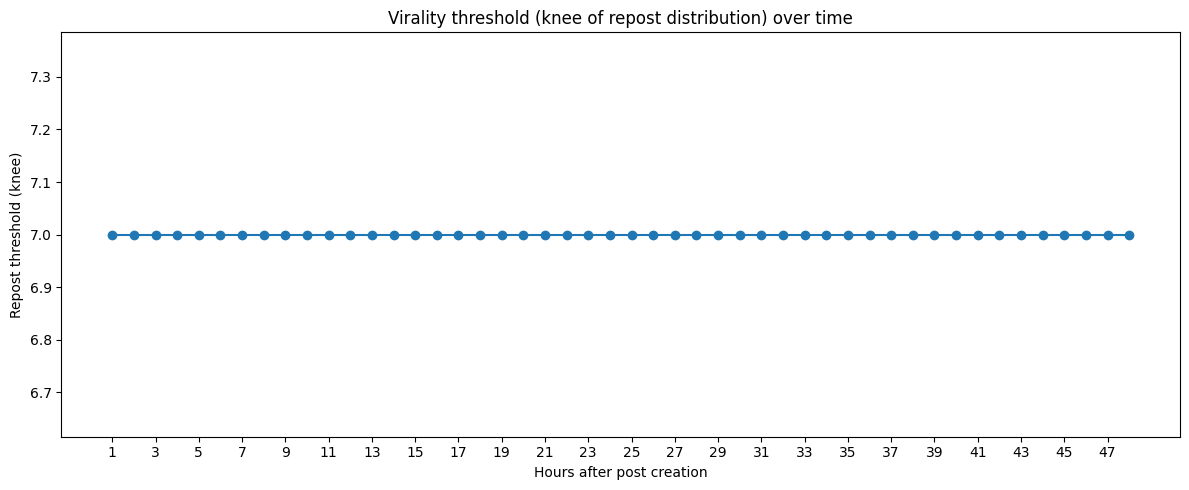

In [ ]:
knee_results = []

for hours in range(MIN_HOURS, MAX_HOURS):
    df = duckdb.query(f"""
        SELECT 
            repost_count,
            COUNT(*) as post_count
        FROM (
            SELECT 
                root_post_uri,
                COUNT(*) as repost_count
            FROM reposts
            WHERE epoch_us(created_at::TIMESTAMPTZ) <= repost_time_us
            AND repost_time_us <= epoch_us(created_at::TIMESTAMPTZ) + ({hours} * 3600::BIGINT * 1000000)
            GROUP BY root_post_uri
        )
        GROUP BY repost_count
        ORDER BY repost_count
    """).df()

    try:
        kneedle = KneeLocator(
            df["repost_count"],
            df["post_count"],
            curve="convex",
            direction="decreasing"
        )
        knee = kneedle.knee
    except Exception as e:
        knee = None

    knee_results.append({"hours": hours, "knee": knee})
    print(f"Hour {hours:2d}: knee at {knee} reposts")

knee_df = pd.DataFrame(knee_results)

# Plot knee over time
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(knee_df["hours"], knee_df["knee"], marker="o")
ax.set_xlabel("Hours after post creation")
ax.set_ylabel("Repost threshold (knee)")
ax.set_title("Virality threshold (knee of repost distribution) over time")
ax.set_xticks(range(1, 49, 2))
plt.tight_layout()
plt.show()